# Contexte
Une entreprise souhaite développer un système capable de classer automatiquement des avis
clients afin d'identifier leur sentiment.
Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction,

réseaux sociaux et service client.
Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe,
majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères,
textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes.
Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent
donc construire un pipeline complet de préparation des données textuelles.

In [2]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Texte / NLP
import re
import string

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

# Vectorisation et split
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy import sparse


[nltk_data] Downloading package punkt to /home/adama/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/adama/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/adama/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Partie 1 – Exploration du corpus

## 1) Charger les données CSV ;

In [3]:
df = pd.read_csv("../data/smart_reviews_raw.csv")
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


## 2) Combien d'avis contient le dataset ?

In [4]:
nb_avis = df.shape[0]
print(f"Le dataset contient {nb_avis} avis.")

Le dataset contient 1200 avis.


## 3) Combien de colonnes possède-t-il ?

In [5]:
nb_colonnes = df.shape[1]
print(f"Le dataset possède {nb_colonnes} colonnes : {list(df.columns)}")

Le dataset possède 8 colonnes : ['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


## 4) Quel est le type de chaque colonne ?

In [6]:
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

## 5) Existe-t-il des valeurs manquantes ?

In [7]:
df.isna().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

On voit qu'il manque quelques valeurs dans la colonne `texte`.

## 6) Identifier quelques types de texte 

Affichons par exemple : texte normal ; texte vide ; texte contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec répétition de caractères.

In [8]:
def afficher_exemple(titre, mask):
    exemples = df.loc[mask, "texte"].dropna()
    print(f"--- {titre} ({mask.sum()} avis) ---")
    if len(exemples) > 0:
        print(exemples.iloc[0])
    else:
        print("Aucun exemple trouvé")
    print()

texte = df["texte"].fillna("").astype(str)

afficher_exemple("Texte normal", ~texte.str.contains(r"http|@\w+|#\w+", na=False) & (texte.str.len() > 10))
afficher_exemple("Texte vide / manquant", df["texte"].isna() | (texte.str.strip() == ""))
afficher_exemple("Texte avec une URL", texte.str.contains(r"http", case=False, na=False))
afficher_exemple("Texte avec une mention (@...)", texte.str.contains(r"@\w+", na=False))
afficher_exemple("Texte avec un hashtag (#...)", texte.str.contains(r"#\w+", na=False))
afficher_exemple("Texte avec des emojis", texte.str.contains(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]", na=False))
afficher_exemple("Texte avec beaucoup de ponctuation", texte.str.count(r"[!?.]{2,}") > 0)
afficher_exemple("Texte en majuscules", (texte.str.upper() == texte) & (texte.str.len() > 5))
afficher_exemple("Texte avec répétition de caractères", texte.str.contains(r"(.)\1{2,}", na=False))

--- Texte normal (795 avis) ---
Très  bonne  expérience,  simple  et  efficace.

--- Texte vide / manquant (6 avis) ---
   

--- Texte avec une URL (143 avis) ---
Produit parfait, rien à signaler. https://example.com/commande/17

--- Texte avec une mention (@...) (128 avis) ---
@client Livraison rapide et produit conforme à mes attentes.

--- Texte avec un hashtag (#...) (127 avis) ---
Très satisfait de mon achat 👍 #avis

--- Texte avec des emojis (192 avis) ---
Très satisfait de mon achat 👍 #avis

--- Texte avec beaucoup de ponctuation (141 avis) ---
Produit excellent, je suis très satisfait. !!!

--- Texte en majuscules (144 avis) ---
LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.

--- Texte avec répétition de caractères (165 avis) ---
Produit excellent, je suis très satisfait. !!!



/tmp/ipykernel_6387/73329858.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  afficher_exemple("Texte avec répétition de caractères", texte.str.contains(r"(.)\1{2,}", na=False))


## 7) Mesurer la longueur des textes
On crée une nouvelle colonne « longueur » pour déterminer : longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles.

In [9]:
df["longueur"] = df["texte"].fillna("").astype(str).apply(len)

stats_longueur = df["longueur"].describe(percentiles=[0.25, 0.5, 0.75])
print(stats_longueur)

print(f"\nLongueur minimale : {df['longueur'].min()}")
print(f"Longueur maximale : {df['longueur'].max()}")
print(f"Longueur moyenne  : {df['longueur'].mean():.1f}")
print(f"Longueur médiane  : {df['longueur'].median()}")

count    1200.000000
mean       48.963333
std        22.350913
min         0.000000
25%        37.000000
50%        48.000000
75%        56.000000
max       636.000000
Name: longueur, dtype: float64

Longueur minimale : 0
Longueur maximale : 636
Longueur moyenne  : 49.0
Longueur médiane  : 48.0


## 8) Visualiser la distribution de la longueur des avis puis répondre aux questions

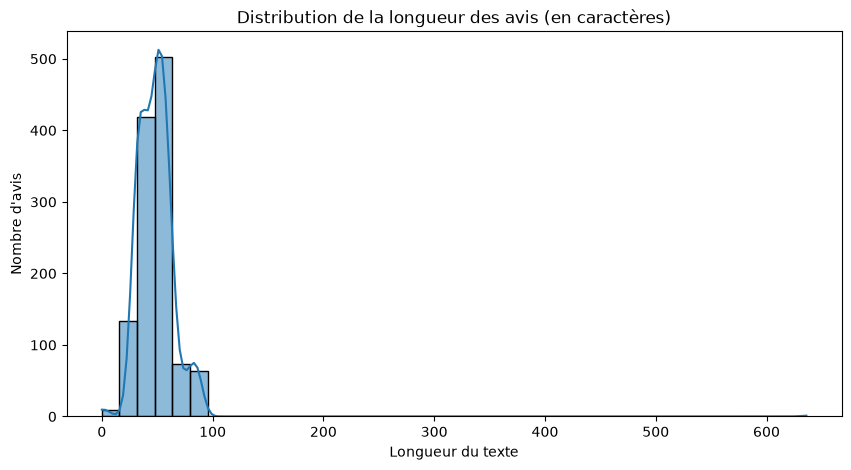

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df["longueur"], bins=40, kde=True)
plt.title("Distribution de la longueur des avis (en caractères)")
plt.xlabel("Longueur du texte")
plt.ylabel("Nombre d'avis")
plt.show()

**a) Existe-t-il des textes anormalement longs ?**

Oui. L’histogramme montre une distribution principalement concentrée sur les textes courts et moyens, avec une longue traîne vers la droite. Quelques avis sont donc nettement plus longs que la majorité et peuvent être considérés comme des valeurs atypiques.

**b) Existe-t-il beaucoup de textes très courts ?**

Non, les textes de moins de 20 caractères restent minoritaires. La majorité des avis se situe plutôt autour de 40 à 60 caractères, même si quelques avis très courts sont présents.

## 9) Détecter les textes vides

In [11]:
masque_vide = df["texte"].isna() | (df["texte"].fillna("").astype(str).str.strip() == "")
nb_vides = masque_vide.sum()
print(f"Nombre de textes vides ou manquants : {nb_vides}")
df[masque_vide]

Nombre de textes vides ou manquants : 6


,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
46,AV0047,2026-02-24,réseaux_sociaux,SmartWatch Pro,NaN,positif,4,fr,0
108,AV0109,2026-01-24,email,SmartPhone Y,NaN,positif,5,fr,0
310,AV0311,2026-02-13,réseaux_sociaux,Ordinateur NovaBook,NaN,positif,5,fr,0
640,AV0641,2026-08-25,réseaux_sociaux,SmartPhone Y,NaN,positif,5,fr,0
781,AV0782,2026-05-21,email,SmartPhone Y,NaN,neutre,4,fr,0
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr,3


## 10) Détecter les doublons sur le texte

In [12]:
masque_doublons = df.duplicated(subset="texte", keep=False)
nb_doublons = df.duplicated(subset="texte", keep="first").sum()
print(f"Nombre d'avis strictement dupliqués (texte identique) : {nb_doublons}")
df[masque_doublons].sort_values("texte").head(10)

Nombre d'avis strictement dupliqués (texte identique) : 881


,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
312,AV0313,2026-04-18,mobile,Écouteurs AirSound,@client Excellent rapport qualité-prix.,positif,4,fr,39
419,AV0420,2026-04-11,sav,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
1099,AV1100,2026-06-30,email,Tablette TabPlus,@client Excellent rapport qualité-prix.,positif,5,fr,39
45,AV0046,2026-08-26,web,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
466,AV0467,2026-07-04,mobile,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
1059,AV1060,2026-01-24,email,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
146,AV0147,2026-08-11,mobile,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
593,AV0594,2026-06-11,mobile,SmartWatch Pro,@client Excellent rapport qualité-prix.,positif,4,fr,39
611,AV0612,2026-03-02,web,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
398,AV0399,2026-07-14,email,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39


## 11) Les classes sont-elles équilibrées ?

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

sentiment
positif    64.7
neutre     20.5
negatif    14.8
Name: proportion, dtype: float64


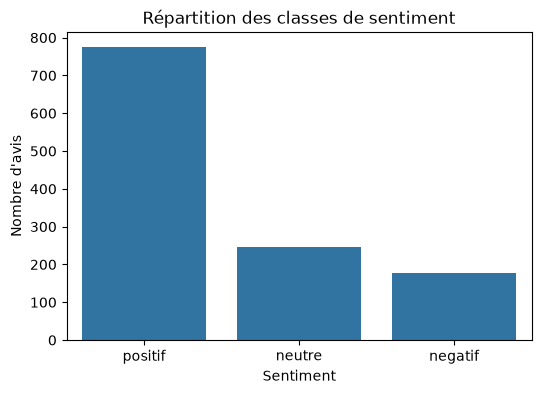

In [13]:
repartition_sentiment = df["sentiment"].value_counts()
repartition_pct = df["sentiment"].value_counts(normalize=True) * 100

print(repartition_sentiment)
print()
print(repartition_pct.round(1))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sentiment", order=repartition_sentiment.index)
plt.title("Répartition des classes de sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Nombre d'avis")
plt.show()

Non, les classes ne sont pas équilibrées : la classe `positif` domine largement (environ les deux tiers des avis), suivie de `neutre` puis `negatif` qui est très minoritaire. C'est un déséquilibre de classes classique en analyse de sentiment (les clients satisfaits laissent plus souvent un avis).

## 12) Quelle est la classe majoritaire ?

In [14]:
classe_majoritaire = df["sentiment"].value_counts().idxmax()
print(f"La classe majoritaire est : {classe_majoritaire}")

La classe majoritaire est : positif


## 13) Quelles métriques de classification à envisager d’utiliser ?

Avec des classes déséquilibrées, l'accuracy seule est trompeuse (un modèle qui prédit toujours `positif` aurait déjà un score élevé). Il vaut mieux privilégier :
- le **F1-score** (macro ou pondéré), qui équilibre précision et rappel ;
- la **précision** et le **rappel** par classe, surtout pour bien détecter la classe minoritaire `negatif` (souvent la plus critique à identifier en pratique) ;
- la **matrice de confusion**, pour visualiser les erreurs entre classes ;
- éventuellement le **ROC-AUC** ou le **PR-AUC** par classe (en one-vs-rest).

## 14) Détecter les caractères particuliers : emojis ; URLs ; hashtags ; mentions ; chiffres ; caractères spéciaux ; ponctuation répétée ; …

In [15]:
caracteres_particuliers = pd.DataFrame({
    "type": ["URL", "Mention (@)", "Hashtag (#)", "Emoji", "Chiffres", "Ponctuation répétée"],
    "nb_avis": [
        texte.str.contains(r"http", case=False, na=False).sum(),
        texte.str.contains(r"@\w+", na=False).sum(),
        texte.str.contains(r"#\w+", na=False).sum(),
        texte.str.contains(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]", na=False).sum(),
        texte.str.contains(r"\d", na=False).sum(),
        texte.str.contains(r"[!?.]{2,}", na=False).sum(),
    ]
})
caracteres_particuliers

,type,nb_avis
0,URL,143
1,Mention (@),128
2,Hashtag (#),127
3,Emoji,192
4,Chiffres,142
5,Ponctuation répétée,141


## 15) Visualiser et commenter nombre d'avis par source

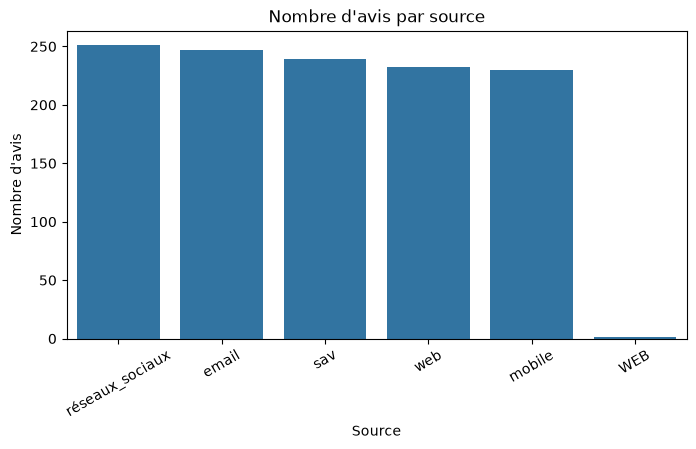

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64

In [16]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="source", order=df["source"].value_counts().index)
plt.title("Nombre d'avis par source")
plt.xlabel("Source")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=30)
plt.show()

df["source"].value_counts()

Les avis sont répartis de façon assez homogène entre les 5 sources principales (web, mobile, sav, email, réseaux sociaux). On remarque aussi une valeur `WEB` en majuscules qui est en réalité la même source que `web` mais mal normalisée dans les données brutes  un point à garder en tête si on avait à nettoyer la colonne `source`.

## 16) Visualiser et commenter le nombre d'avis par produit

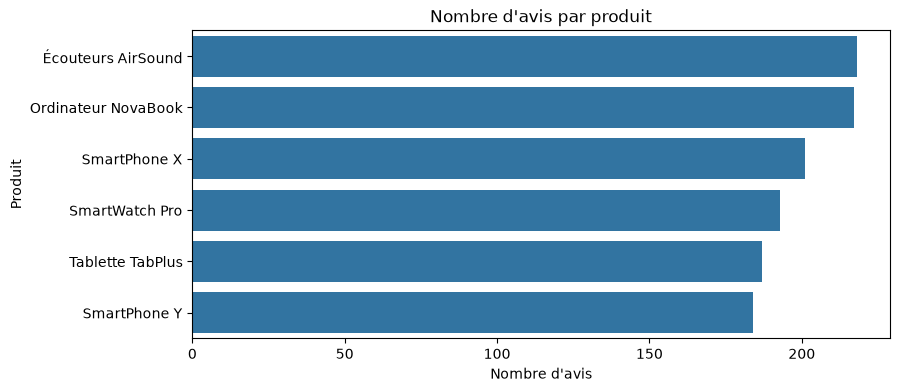

produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64

In [17]:
plt.figure(figsize=(9, 4))
sns.countplot(data=df, y="produit", order=df["produit"].value_counts().index)
plt.title("Nombre d'avis par produit")
plt.xlabel("Nombre d'avis")
plt.ylabel("Produit")
plt.show()

df["produit"].value_counts()

Les avis se répartissent sur plusieurs produits distincts, de façon relativement équilibrée : aucun produit ne domine massivement le corpus, ce qui limite le risque que le futur modèle apprenne un biais lié à un produit en particulier plutôt qu'au sentiment réel exprimé dans le texte.

# Partie 2 – Nettoyage

## 1) Supprimer les lignes contenant des valeurs manquantes de texte

In [18]:
nb_avant = df.shape[0]
df = df.dropna(subset=["texte"]).reset_index(drop=True)
nb_apres = df.shape[0]
print(f"{nb_avant - nb_apres} ligne(s) supprimée(s) pour texte manquant. Il reste {nb_apres} avis.")

5 ligne(s) supprimée(s) pour texte manquant. Il reste 1195 avis.


## 2) Supprimer les doublons

In [19]:
nb_avant = df.shape[0]
df = df.drop_duplicates(subset="texte").reset_index(drop=True)
nb_apres = df.shape[0]
print(f"{nb_avant - nb_apres} doublon(s) supprimé(s). Il reste {nb_apres} avis.")

877 doublon(s) supprimé(s). Il reste 318 avis.


## 3) Supprimer les URLs

In [20]:
def supprimer_urls(texte):
    return re.sub(r"http\S+|www\.\S+", "", texte)

# Test rapide sur un exemple
exemple = df.loc[df["texte"].str.contains("http", case=False), "texte"].iloc[0]
print("Avant :", exemple)
print("Après :", supprimer_urls(exemple))

Avant : Produit parfait, rien à signaler. https://example.com/commande/17
Après : Produit parfait, rien à signaler. 


## 4) Traiter les mentions et hashtags avec la stratégie la plus pertinente pour une classification de sentiment

In [21]:
def traiter_mentions_hashtags(texte):
    texte = re.sub(r"@(\w+)", r"\1", texte)   # @client -> client
    texte = re.sub(r"#(\w+)", r"\1", texte)   # #top -> top
    return texte

exemple = df.loc[df["texte"].str.contains("@|#", regex=True), "texte"].iloc[0]
print("Avant :", exemple)
print("Après :", traiter_mentions_hashtags(exemple))

Avant : Très satisfait de mon achat 👍 #avis
Après : Très satisfait de mon achat 👍 avis


## 5) Nettoyer les espaces

In [22]:
def nettoyer_espaces(texte):
    return re.sub(r"\s+", " ", texte).strip()

exemple = "Très   bonne  expérience,   simple  et efficace.   "
print("Avant :", repr(exemple))
print("Après :", repr(nettoyer_espaces(exemple)))

Avant : 'Très   bonne  expérience,   simple  et efficace.   '
Après : 'Très bonne expérience, simple et efficace.'


## 6) Traiter la ponctuation avec la stratégie la plus pertinente pour une classification de sentiment

In [23]:
def reduire_repetitions(texte):
    # "supeeeer" -> "super", "!!!" -> "!"
    return re.sub(r"(.)\1{2,}", r"\1\1", texte)

def supprimer_ponctuation(texte):
    return texte.translate(str.maketrans("", "", string.punctuation))

exemple = "Produit excellent, je suis très satisfait !!!"
etape1 = reduire_repetitions(exemple)
etape2 = supprimer_ponctuation(etape1)
print("Avant  :", exemple)
print("Étape 1 (répétitions réduites) :", etape1)
print("Étape 2 (ponctuation supprimée) :", etape2)

Avant  : Produit excellent, je suis très satisfait !!!
Étape 1 (répétitions réduites) : Produit excellent, je suis très satisfait !!
Étape 2 (ponctuation supprimée) : Produit excellent je suis très satisfait 


## 7) Créer une fonction de nettoyage pour automatiser les actions ci-dessus

In [24]:
def nettoyer_texte(texte):
    texte = str(texte)
    texte = supprimer_urls(texte)
    texte = traiter_mentions_hashtags(texte)
    texte = reduire_repetitions(texte)
    texte = supprimer_ponctuation(texte)
    texte = nettoyer_espaces(texte)
    return texte

## 8) Stocker sur une colonne texte_clean, les textes ayant subi les traitements ci-dessus

In [25]:
df["texte_clean"] = df["texte"].apply(nettoyer_texte)
df[["texte_clean"]].head()

,texte_clean
0,Très bonne expérience simple et efficace
1,Très satisfait de mon achat 👍 avis
2,Produit parfait rien à signaler
3,Produit excellent je suis très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET LÉCRAN EST ...


## 9) Vérifier le contenu des colonnes texte et texte_clean sur les 10 premières observations

In [26]:
df[["texte", "texte_clean"]].head(10)

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.",Très bonne expérience simple et efficace
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat 👍 avis
2,"Produit parfait, rien à signaler.",Produit parfait rien à signaler
3,"Produit excellent, je suis très satisfait. !!!",Produit excellent je suis très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET LÉCRAN EST ...
5,Très satisfait de mon achat 👍 😊,Très satisfait de mon achat 👍 😊
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7,Très satisfait de mon achat 👍,Très satisfait de mon achat 👍
8,Le produit correspond globalement à la d...,Le produit correspond globalement à la descrip...
9,@client Livraison rapide et produit conforme à...,client Livraison rapide et produit conforme à ...


# Partie 3 – Tokenisation

## 1) Pourquoi split() n'est-il pas suffisant pour une vraie application NLP ?

`str.split()` se contente de couper le texte sur les espaces. Il ne gère pas correctement :
- la ponctuation collée aux mots (`"efficace."` reste un seul token au lieu de `"efficace"` + `"."`) ;
- les contractions et l'apostrophe française (`"j'aime"` devrait souvent être séparé en `"j'"` + `"aime"`) ;
- les cas particuliers de tokenisation linguistique (nombres, abréviations, etc.).

Un vrai tokenizer NLP (comme celui de NLTK) applique des règles linguistiques plus fines pour découper le texte en unités lexicales cohérentes.

## 2) Utiliser la bibliothèque NLTK pour déterminer :

### a) le nombre de tokens de chaque texte,

In [27]:
df["tokens"] = df["texte_clean"].apply(lambda t: word_tokenize(t, language="french"))
df["nb_tokens"] = df["tokens"].apply(len)

df[["texte_clean", "nb_tokens"]].head()

,texte_clean,nb_tokens
0,Très bonne expérience simple et efficace,6
1,Très satisfait de mon achat 👍 avis,7
2,Produit parfait rien à signaler,5
3,Produit excellent je suis très satisfait,6
4,LA BATTERIE TIENT VRAIMENT BIEN ET LÉCRAN EST ...,9


### b) nombre moyen de tokens ;

In [28]:
nb_tokens_moyen = df["nb_tokens"].mean()
print(f"Nombre moyen de tokens par avis : {nb_tokens_moyen:.2f}")

Nombre moyen de tokens par avis : 6.91


### c) texte avec le plus grand nombre de tokens ;

In [29]:
idx_max = df["nb_tokens"].idxmax()
idx_min = df["nb_tokens"].idxmin()

print(f"\nTexte avec le PLUS de tokens ({df.loc[idx_max, 'nb_tokens']} tokens) :")
print(df.loc[idx_max, "texte_clean"])


Texte avec le PLUS de tokens (120 tokens) :
Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue


### d) texte avec le plus petit nombre de tokens.

In [30]:
print(f"\nTexte avec le MOINS de tokens ({df.loc[idx_min, 'nb_tokens']} tokens) :")
print(df.loc[idx_min, "texte_clean"])


Texte avec le MOINS de tokens (0 tokens) :



# Partie 4 – Normalisation

## 1) Uniformiser la casse en minuscules. Pourquoi ce traitement ?

Sans cette étape, `"Bon"`, `"bon"` et `"BON"` seraient considérés comme trois mots différents par le vectoriseur, alors qu'ils portent le même sens. Mettre tout en minuscules réduit la taille du vocabulaire et évite de diluer le signal statistique sur un même mot écrit de différentes façons.

In [31]:
df["texte_clean"] = df["texte_clean"].str.lower()
df["texte_clean"].head()

0             très bonne expérience simple et efficace
1                   très satisfait de mon achat 👍 avis
2                      produit parfait rien à signaler
3             produit excellent je suis très satisfait
4    la batterie tient vraiment bien et lécran est ...
Name: texte_clean, dtype: str

## 2) Faut-il systématiquement supprimer les accents dans un corpus français ?

Non, pas systématiquement. Les accents portent du sens en français (`"a"` vs `"à"`, `"ou"` vs `"où"`) et les supprimer peut créer des collisions entre mots différents (ex : `"pêche"` le fruit vs `"peche"`). On peut les supprimer si on utilise un modèle très simple (bag-of-words) et qu'on veut réduire encore le vocabulaire, ou si le corpus contient beaucoup de fautes de frappe sur les accents (comme précisé dans le contexte de cet atelier) — c'est justement le cas ici, donc on choisit de les supprimer pour homogénéiser un corpus où les accents sont utilisés de façon incohérente.

In [32]:
import unicodedata

def supprimer_accents(texte):
    texte_nfkd = unicodedata.normalize("NFKD", texte)
    return "".join(c for c in texte_nfkd if not unicodedata.combining(c))

df["texte_clean"] = df["texte_clean"].apply(supprimer_accents)
df["texte_clean"].head()

0             tres bonne experience simple et efficace
1                   tres satisfait de mon achat 👍 avis
2                      produit parfait rien a signaler
3             produit excellent je suis tres satisfait
4    la batterie tient vraiment bien et lecran est ...
Name: texte_clean, dtype: str

## 3) Quels stop words supprimer ?

Les mots grammaticaux très fréquents et peu porteurs de sens à eux seuls pour le sentiment : articles (`le`, `la`, `les`), pronoms (`je`, `il`, `nous`), prépositions (`de`, `à`, `pour`), conjonctions (`et`, `mais`, `ou`), auxiliaires (`être`, `avoir`) — la liste standard de stop words français de NLTK.

## 4) Quels stop words conserver ?

Les mots de **négation** (`ne`, `pas`, `plus`, `jamais`, `aucun`) doivent être conservés : ils inversent complètement le sens d'une phrase (`"pas bon"` ≠ `"bon"`). Les supprimer ferait perdre une information essentielle pour la classification de sentiment.

In [33]:
stop_words_fr = set(stopwords.words("french"))

mots_negation = {"ne", "pas", "plus", "jamais", "aucun", "aucune", "rien", "personne", "ni"}
stop_words_fr = stop_words_fr - mots_negation

print(f"Nombre de stop words retenus : {len(stop_words_fr)}")
print("Exemples de mots de négation conservés :", mots_negation)

Nombre de stop words retenus : 155
Exemples de mots de négation conservés : {'aucune', 'aucun', 'rien', 'ni', 'ne', 'jamais', 'plus', 'personne', 'pas'}


## 5) Appliquer la technique (stemming ou lemmatisation) la plus adaptée ?

NLTK ne propose pas de lemmatiseur français fiable "prêt à l'emploi" (contrairement à l'anglais avec WordNet), et installer un modèle de lemmatisation français demanderait une dépendance supplémentaire plus lourde (ex : spaCy + modèle français). Pour garder un pipeline **simple et reproductible**, on utilise donc le **stemming** avec le `SnowballStemmer` français de NLTK, qui réduit les mots à leur racine (`"aimait"`, `"aimer"`, `"aimée"` → `"aim"`) de façon simple et rapide, même si le résultat est moins "propre" linguistiquement qu'une lemmatisation.

In [35]:
stemmer = SnowballStemmer("french")

def normaliser_texte(texte):
    tokens = word_tokenize(texte, language="french")
    tokens = [t for t in tokens if t not in string.punctuation]      # enlever ponctuation résiduelle
    tokens = [t for t in tokens if t not in stop_words_fr]           # enlever stop words (sauf négations)
    tokens = [stemmer.stem(t) for t in tokens]                       # stemming
    return " ".join(tokens)

# Test sur un exemple
exemple = df["texte_clean"].iloc[2]
print("Avant :", exemple)
print("Après :", normaliser_texte(exemple))

Avant : produit parfait rien a signaler
Après : produit parf rien a signal


## 6) Stocker sur une colonne « texte_final », les textes ayant subi le nettoyage et les traitements ci-dessus

In [36]:
df["texte_final"] = df["texte_clean"].apply(normaliser_texte)
df[["texte_clean", "texte_final"]].head()

,texte_clean,texte_final
0,tres bonne experience simple et efficace,tre bon experient simpl efficac
1,tres satisfait de mon achat 👍 avis,tre satisf achat 👍 avis
2,produit parfait rien a signaler,produit parf rien a signal
3,produit excellent je suis tres satisfait,produit excellent tre satisf
4,la batterie tient vraiment bien et lecran est ...,batter tient vrai bien lecran superb
